# Wine Quality ML - Classificação

Análise da qualidade de vinhos tintos (`winequality-red.csv`) com aprendizado supervisionado. Objetivo: prever se um vinho é de qualidade **baixa** ou **alta** a partir das características físico-químicas.


##  Conhecer os dados

Carregamento do dataset e inspeção inicial: quantidade de registros e atributos, valores mínimos/máximos de cada coluna (para identificar diferenças de escala) e a distribuição da variável `quality`.


In [32]:
import pandas as pd

# Leitura do arquivo e criação do DataFrame
df = pd.read_csv('D:/.git/Machine_learning_unifor/data/winequality-red.csv', sep=';')

print(df.describe().loc[["min", "max"]])
print(df.max().sort_values())


     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
min            4.6              0.12          0.0             0.9      0.012   
max           15.9              1.58          1.0            15.5      0.611   

     free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
min                  1.0                   6.0  0.99007  2.74       0.33   
max                 72.0                 289.0  1.00369  4.01       2.00   

     alcohol  quality  
min      8.4      3.0  
max     14.9      8.0  
chlorides                 0.61100
citric acid               1.00000
density                   1.00369
volatile acidity          1.58000
sulphates                 2.00000
pH                        4.01000
quality                   8.00000
alcohol                  14.90000
residual sugar           15.50000
fixed acidity            15.90000
free sulfur dioxide      72.00000
total sulfur dioxide    289.00000
dtype: float64


Distribuição das notas originais de `quality` (escala de 3 a 8):

In [33]:
df["quality"].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

##  Criar a variável binária de qualidade

Regra do enunciado: qualidade **baixa** (`quality < 6`, valor 0) e qualidade **alta** (`quality >= 6`, valor 1). Em seguida verificamos o balanceamento das duas classes.


In [34]:
# comparação gera True/False; astype(int) converte para 1/0
df["avaliacao"] = (df["quality"] >= 6).astype(int)
df["avaliacao"].value_counts(normalize=True)


avaliacao
1    0.534709
0    0.465291
Name: proportion, dtype: float64

##  Separar treino e teste

Divisão 80/20 com `random_state` fixo (reprodutibilidade) e `stratify=y` (mantém a proporção 53/47 em treino e teste). A `quality` é removida de `X` junto com `avaliacao`, pois foi ela que deu origem ao rótulo - mantê-la seria vazamento de dados (o modelo teria acesso direto à resposta).


In [35]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["avaliacao", "quality"])  # features
y = df["avaliacao"]                             # o que prever

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y,
    test_size=0.2,       # 20% para teste
    random_state=42,     # mesma divisão a cada execução
    stratify=y,          # mantém a proporção das classes
)

print("X_treino:", X_treino.shape)
print("X_teste: ", X_teste.shape)
print("y_treino:", y_treino.shape)
print("y_teste: ", y_teste.shape)


X_treino: (1279, 11)
X_teste:  (320, 11)
y_treino: (1279,)
y_teste:  (320,)


## Padronizar e treinar os modelos

As colunas têm escalas muito diferentes (ex.: `total sulfur dioxide` chega a 289, `chlorides` no máximo 0,611). Por isso os dados são padronizados com `StandardScaler` antes do treino - `fit` só no treino, `transform` no teste, para não vazar informação do teste para o pré-processamento.


In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino_pad = scaler.fit_transform(X_treino)
X_teste_pad = scaler.transform(X_teste)


Dois modelos, escolhidos por não dependerem da mesma forma de distância entre pontos: **Regressão Logística** (fronteira linear, sensível à escala, por isso padronizada) e **Árvore de Decisão** (perguntas sequenciais sobre uma coluna por vez, não usa distância).


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

modelo1 = LogisticRegression(random_state=42)
modelo1.fit(X_treino_pad, y_treino)
prev1 = modelo1.predict(X_teste_pad)

modelo2 = DecisionTreeClassifier(random_state=42)
modelo2.fit(X_treino_pad, y_treino)
prev2 = modelo2.predict(X_teste_pad)


## Avaliar e comparar os modelos

### Acurácia no treino x no teste

Serve para detectar overfitting: um gap grande entre treino e teste indica que o modelo memorizou os dados de treino em vez de aprender o padrão geral.


In [38]:
# Acurácia no treino x teste - Regressão Logística (modelo1)
log_treino = modelo1.score(X_treino_pad, y_treino)
log_teste  = modelo1.score(X_teste_pad, y_teste)

# Acurácia no treino x teste - Árvore de Decisão (modelo2)
arv_treino = modelo2.score(X_treino_pad, y_treino)
arv_teste  = modelo2.score(X_teste_pad, y_teste)

print(f"Regressão Logística -> Treino: {log_treino:.3f} | Teste: {log_teste:.3f}")
print(f"Árvore de Decisão   -> Treino: {arv_treino:.3f} | Teste: {arv_teste:.3f}")


Regressão Logística -> Treino: 0.743 | Teste: 0.741
Árvore de Decisão   -> Treino: 1.000 | Teste: 0.753


**Leitura dos resultados:** a Regressão Logística tem gap quase nulo entre treino e teste (0,743 vs 0,741), ou seja, generaliza de forma consistente. A Árvore de Decisão chega a 1,000 no treino e cai para 0,753 no teste (gap de 0,247) - decorou os exemplos de treino, sinal claro de overfitting. Mesmo assim, a Árvore teve o teste levemente melhor. Isso mostra que gap pequeno (generalização) e valor absoluto no teste (desempenho atual) são dois critérios diferentes, e nenhum decide sozinho qual modelo é o melhor.


### Métricas de classificação

Acurácia sozinha esconde o tipo de erro. Precisão, recall e F1 detalham melhor o desempenho de cada modelo em cada classe.


In [39]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Regressão Logística
acc1  = accuracy_score(y_teste, prev1)
prec1 = precision_score(y_teste, prev1)
rec1  = recall_score(y_teste, prev1)
f1_1  = f1_score(y_teste, prev1)

# Árvore de Decisão
acc2  = accuracy_score(y_teste, prev2)
prec2 = precision_score(y_teste, prev2)
rec2  = recall_score(y_teste, prev2)
f1_2  = f1_score(y_teste, prev2)

print("Regressão Logística - Métricas")
print(f"Acurácia:  {acc1:.3f}")
print(f"Precisão:  {prec1:.3f}")
print(f"Recall:    {rec1:.3f}")
print(f"F1-score:  {f1_1:.3f}")

print("Árvore de Decisão - Métricas")
print(f"Acurácia:  {acc2:.3f}")
print(f"Precisão:  {prec2:.3f}")
print(f"Recall:    {rec2:.3f}")
print(f"F1-score:  {f1_2:.3f}")


Regressão Logística - Métricas
Acurácia:  0.741
Precisão:  0.768
Recall:    0.737
F1-score:  0.752
Árvore de Decisão - Métricas
Acurácia:  0.753
Precisão:  0.764
Recall:    0.778
F1-score:  0.771


### Matriz de confusão

Para cada modelo: linhas = classe real, colunas = classe prevista (ordem 0 = baixa, 1 = alta). Os gráficos são salvos em `results/figures/`.


[[111  38]
 [ 45 126]]


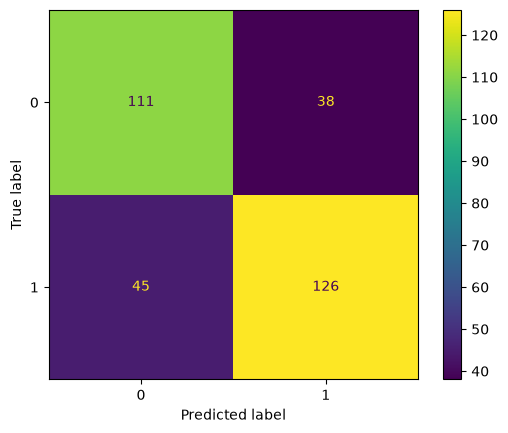

[[108  41]
 [ 38 133]]


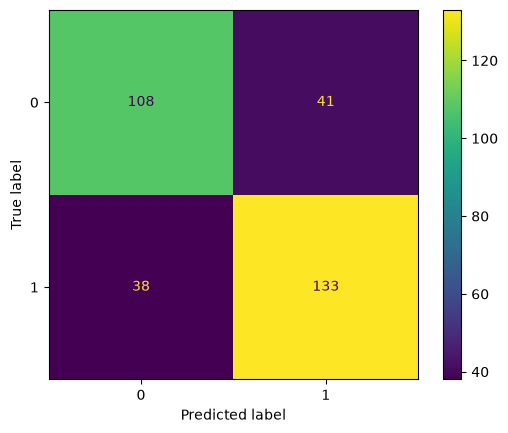

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Regressão Logística
cm = confusion_matrix(y_teste, prev1)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_teste, prev1)
plt.savefig("../results/figures/matriz_regressao.png")
plt.show()

# Árvore de Decisão
cm = confusion_matrix(y_teste, prev2)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_teste, prev2)
plt.savefig("../results/figures/matriz_arvore.png")
plt.show()




**Resultados obtidos:**

| Métrica | Regressão Logística | Árvore de Decisão |
|---|---|---|
| Acurácia | 0,741 | 0,753 |
| Precisão | 0,768 | 0,764 |
| Recall | 0,737 | 0,778 |
| F1-score | 0,752 | 0,771 |
| Gap treino-teste | 0,002 | 0,247 |

**Matrizes de confusão** (real x previsto, 0 = baixa, 1 = alta):

- Regressão Logística: `[[111, 38], [45, 126]]`
- Árvore de Decisão: `[[108, 41], [38, 133]]`




## Agrupamento com K-Means

Aprendizado **não supervisionado**: o algoritmo agrupa os vinhos só pela distância entre as 11 características físico-químicas, sem nunca ver `quality` ou `avaliacao`. O objetivo é ver se existem grupos naturais, e se esses grupos coincidem (ou não) com a qualidade.


In [41]:
from sklearn.preprocessing import StandardScaler

# a variável X (features, sem quality/avaliacao)
scaler_kmeans = StandardScaler()
X_kmeans = scaler_kmeans.fit_transform(X)  # X inteiro, sem split treino/teste


### Rodar o K-Means com pelo menos dois valores de K


In [42]:
from sklearn.cluster import KMeans


kmeans_k1 = KMeans(n_clusters=2, random_state=42, n_init=10)  
grupos_k1 = kmeans_k1.fit_predict(X_kmeans)

kmeans_k2 = KMeans(n_clusters=4, random_state=42, n_init=10)  
grupos_k2 = kmeans_k2.fit_predict(X_kmeans)


### Comparar o tamanho dos grupos em cada K


In [43]:
import pandas as pd


pd.Series(grupos_k1).value_counts()
pd.Series(grupos_k2).value_counts()

print("K1:")
print(pd.Series(grupos_k1).value_counts())
print()
print("K2:")
print(pd.Series(grupos_k2).value_counts())


K1:
1    1009
0     590
Name: count, dtype: int64

K2:
0    553
2    398
3    334
1    314
Name: count, dtype: int64


### Cruzar os grupos encontrados com a qualidade real

Os grupos foram formados sem o algoritmo nunca ver `avaliacao`. Agora comparamos: dentro de cada grupo, quantos vinhos são de qualidade alta e quantos são de baixa?


In [44]:


print("K1:")
print(pd.crosstab(df["avaliacao"], grupos_k1))
print()
print("K2:")
print(pd.crosstab(df["avaliacao"], grupos_k2))


K1:
col_0        0    1
avaliacao          
0          198  546
1          392  463

K2:
col_0        0    1    2    3
avaliacao                    
0          339   53  123  229
1          214  261  275  105


### Comparar as características médias de cada grupo (K=4)

Para saber se os grupos representam vinhos fisicamente diferentes (e não só uma divisão arbitrária), comparamos a média de cada característica dentro de cada grupo.


In [45]:
medias_por_grupo = df.groupby(grupos_k2)[X.columns].mean()
medias_por_grupo.T


,0,1,2,3
fixed acidity,7.505244,7.120064,10.471859,8.231138
volatile acidity,0.650099,0.446975,0.414284,0.536662
citric acid,0.114919,0.242420,0.489523,0.295778
residual sugar,2.239331,2.169268,2.649874,3.249701
chlorides,0.084139,0.067220,0.106980,0.088757
free sulfur dioxide,11.736890,17.568471,10.502513,27.535928
total sulfur dioxide,34.249548,39.585987,30.989950,91.610778
density,0.996621,0.994457,0.998100,0.997494
pH,3.371121,3.409490,3.172714,3.284192
sulphates,0.589385,0.679809,0.760302,0.629910




**1. Que diferenças foram observadas ao mudar o número de grupos (K)?**

Com K=2, os grupos ficaram desiguais em tamanho (590 e 1009) e nenhum dos dois é puro: o grupo mais próximo disso tem 198 vinhos baixos contra 392 altos (66,4% de uma classe). Com K=4, os grupos ficam com tamanhos mais parecidos entre si (553, 314, 398 e 334), mas a separação por qualidade fica **mais** marcada em alguns deles, não menos: o grupo 1 chega a 83,1% de uma única classe (261 de 314 vinhos são 'alta'), bem mais puro que qualquer grupo do K=2. Ou seja, aumentar o K não deixou a mistura de qualidade mais uniforme - criou grupos menores e mais específicos, e alguns desses grupos acabaram concentrando mais vinhos de uma classe.

**2. Os grupos encontrados parecem representar conjuntos distintos de vinhos?**

Sim, e isso é sustentado pela média das características físico-químicas em cada grupo (K=4), não só pela proporção de qualidade. Por exemplo, o grupo 3 tem `total sulfur dioxide` médio de ~91,6, bem acima dos outros grupos (31 a 40); o grupo 2 tem `fixed acidity` e `citric acid` mais altos (10,5 e 0,49); o grupo 1 tem o maior teor alcoólico médio (11,7) e a menor `volatile acidity` (0,45). Cada grupo tende a se destacar em atributos diferentes, o que indica que o K-Means encontrou padrões reais nos dados, não uma divisão aleatória.

**3. Os agrupamentos coincidem necessariamente com as classes de qualidade? O que a tabela cruzada (`crosstab`) mostrou?**

Não coincidem totalmente. Com K=4, a classe majoritária de cada grupo varia de 61,3% (grupo 0) a 83,1% (grupo 1), ou seja, mesmo o grupo mais 'puro' ainda tem quase 17% de vinhos da outra classe misturados. Isso mostra uma coincidência **parcial**: os grupos captam algo relacionado à qualidade (senão as proporções seriam todas próximas de 50/50), mas não reproduzem a divisão binária baixa/alta com pureza - o K-Means está agrupando por semelhança físico-química geral, e qualidade é só um dos fatores que correlaciona com isso, não o único.


## Redução de dimensionalidade com PCA

Reduzir as 11 características físico-químicas para **2 componentes principais** (PC1 e PC2), que resumem o máximo possível da variação dos dados originais, e visualizar tudo em um gráfico de dispersão 2D.


### Aplicar o PCA

Use os dados já padronizados (`X_kmeans`, da etapa de K-Means - mesmo princípio: distância entre pontos, então precisa estar na mesma escala). `n_components=2` reduz para 2 eixos.


In [46]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
componentes = pca.fit_transform(X_kmeans)



### Quanto de informação os 2 componentes preservam?

`pca.explained_variance_ratio_` mostra, para cada componente, a fração da variância total dos dados originais que ele captura. Some os dois valores para saber o total preservado em 2D.


In [47]:
print(pca.explained_variance_ratio_)
print("Soma:", pca.explained_variance_ratio_.sum())


[0.28173931 0.1750827 ]
Soma: 0.4568220118429404


### Gráfico de dispersão (PC1 x PC2)

Scatter plot com PC1 no eixo X e PC2 no eixo Y, colorido pela classe de qualidade (`avaliacao`). A figura é salva em `results/figures/pca.png`.


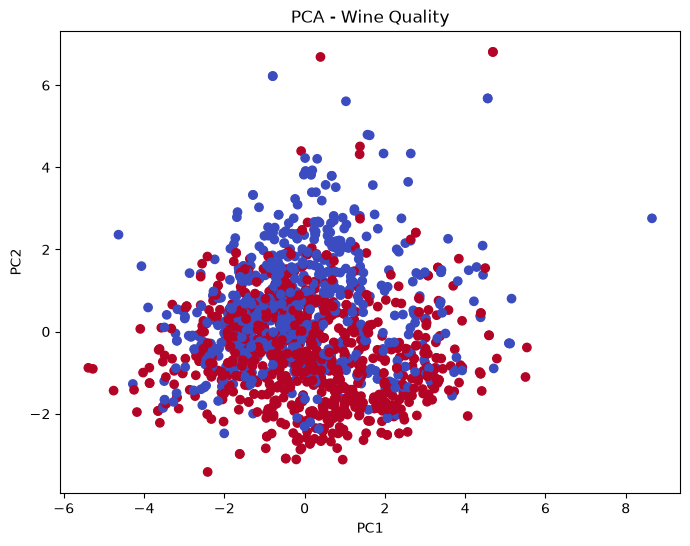

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(componentes[:, 0], componentes[:, 1], c=df["avaliacao"], cmap="coolwarm")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA - Wine Quality")

plt.savefig("../results/figures/pca.png")
plt.show()


### Conclusão do PCA

**1. Quanto da informação original os 2 componentes preservam?**

Os componentes preservam apenas 45,7% da variância dos dados, mais da metade da informação original não está no gráfico, isso é pouco, perdemos mais da metade da informação ao reduzir de 11 para 2 dimensões.

**2. É possível observar regiões ou grupos distintos no gráfico?**

Não, a parte no centro está tudo misturado, mas nas bordas há uma leve tendência para qualidade baixa.

**3. Existem grupos muito sobrepostos?**

Como não há duas nuvens separadas, praticamente toda a massa de pontos está sobreposta, exceto talvez alguns poucos pontos isolados nas bordas.

**4. A representação em 2D parece preservar informações relevantes dos dados, ou parece ter perdido demais para ser útil?**

Parece ter perdido demais para ser útil, já que perdeu mais da metade da variância. A separação por qualidade existe nos dados originais em 11 dimensões (como vimos no K-Means, que chegou a 83,1% de pureza em um dos grupos), mas se perde quando comprimimos para 2D - a visualização não preserva o suficiente para servir como ferramenta de decisão sozinha.


### Resposta final

**Sim, Machine Learning seria útil para a empresa analisar a qualidade dos vinhos, mas como uma ferramenta de apoio, não como um substituto total da avaliação humana.**

**Desempenho dos modelos supervisionados.** Os dois modelos treinados (Regressão Logística e Árvore de Decisão) conseguiram prever a qualidade (baixa/alta) com acurácia de 74,1% e 75,3% no conjunto de teste, respectivamente. Isso é claramente melhor do que simplesmente 'chutar' a classe mais comum, o que acertaria cerca de 53,5% das vezes. Ou seja, existe sinal real nas características físico-químicas que ajuda a prever a qualidade - não é um resultado aleatório. Olhando além da acurácia, a Árvore teve recall um pouco maior (77,8% contra 73,7% da Logística), encontrando mais vinhos de qualidade alta corretamente, enquanto a Logística generalizou de forma mais estável (gap de apenas 0,002 entre treino e teste, contra 0,247 da Árvore, que decorou boa parte do treino).

**Limitações observadas.** Nenhum dos dois modelos passou de 76-77% em qualquer métrica, o que está longe de uma previsão confiável o suficiente para decisões automáticas de controle de qualidade sem revisão humana. A Árvore de Decisão, além disso, mostrou sinais de overfitting (acurácia de 100% no treino contra 75,3% no teste), o que significa que ela memorizou parte dos exemplos de treino em vez de aprender só o padrão geral - um modelo assim tende a ser menos confiável em vinhos com características bem diferentes das que ele já viu. Isso sugere que as 11 características físico-químicas usadas carregam informação parcial sobre a qualidade, mas não capturam tudo o que influencia a nota atribuída a um vinho (por exemplo, aspectos sensoriais avaliados por humanos que não estão no dataset).

**Padrões encontrados pelo agrupamento (K-Means).** Ao ignorar a qualidade e agrupar os vinhos só pelas características físico-químicas, o K-Means encontrou grupos com identidade própria (por exemplo, um grupo com teor alcoólico mais alto e menor acidez volátil, outro com `total sulfur dioxide` bem acima da média). Isso mostra que existem sim tipos naturais de vinho na base. Esses grupos se relacionam com a qualidade, mas de forma parcial: com K=4, a proporção da classe majoritária em cada grupo variou de 61,3% a 83,1% - nenhum grupo ficou 'puro' em uma única classe. Isso reforça a limitação anterior: a estrutura físico-química dos vinhos não se alinha perfeitamente com a divisão binária de qualidade usada no projeto.

**Contribuição da visualização com PCA.** Reduzir as 11 características para 2 componentes principais preservou apenas 45,7% da variância total dos dados, e o gráfico de dispersão resultante mostrou os vinhos de qualidade baixa e alta bastante sobrepostos, sem duas regiões claramente separadas. Isso não significa que a qualidade seja totalmente aleatória (os modelos supervisionados, usando as 11 dimensões completas, conseguiram superar o chute aleatório), mas sim que a separação entre as classes, quando existe, depende de uma combinação de várias características ao mesmo tempo, mais do que conseguimos representar em apenas 2 eixos para fins de visualização.

**Conclusão.** Machine Learning tem utilidade real para a empresa: os modelos supervisionados superam uma estimativa aleatória de forma consistente, e o agrupamento revela categorias naturais de vinhos que poderiam orientar decisões de produção ou de blend. Mas os resultados também mostram limitações claras - acurácia na casa dos 75%, sobreposição visível entre classes e indícios de overfitting em pelo menos um dos modelos - que impedem tratar essas previsões como definitivas. Na prática, o caminho mais responsável é usar esses modelos como uma **triagem inicial de apoio** ao controle de qualidade (por exemplo, sinalizando amostras prováveis de qualidade baixa para reavaliação humana prioritária), e não como substituto da avaliação especializada.
